In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import timm


from paddy_10_data_loader import load_train_val_data
from shufflenet_v2 import ShuffleNetV2

from kd_utils import student_training_loop, evaluate
from helper_utils import count_params

import numpy as np
import matplotlib.pyplot as plt


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## ShuffleNetV2 as a student model with knowledge distillation

In [3]:
densenet_201_teacher = timm.create_model("densenet201", pretrained=False, num_classes=10)
densenet_201_teacher.load_state_dict(torch.load("densenet_201_teacher.pth"))

<All keys matched successfully>

In [4]:
count_params(ShuffleNetV2(n_class=10, model_size="0.90x"))

model size is  0.90x
Total Parameters:         1,191,708
Trainable Parameters:     1,176,232
Non-trainable Parameters: 15,476


In [5]:
epochs = 15
lr = 0.01
eta_min = 0.001

In [6]:
train_loader, val_loader = load_train_val_data(batch_size=32)
shufflenet_v2_student1 = ShuffleNetV2(n_class=10, model_size="0.90x")
shufflenet_v2_student_loss1 = nn.CrossEntropyLoss()
shufflenet_v2_student_optimizer1 = optim.Adam(shufflenet_v2_student1.parameters(), lr=lr)
lr_scheduler1 = optim.lr_scheduler.CosineAnnealingLR(shufflenet_v2_student_optimizer1, T_max=epochs, eta_min=eta_min)

trained_shufflenet_v2_student1, shufflenet_v2_student_history1 = student_training_loop(
   teacher=densenet_201_teacher,
   student=shufflenet_v2_student1,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=shufflenet_v2_student_optimizer1,
    temperature=4,
    alpha=0.90,
    num_epochs=epochs,
    device=device,
    scheduler=lr_scheduler1,
    save_path= "shufflenet_v2_student_extended_1.pth",
)

model size is  0.90x


Overall Progress:   0%|          | 0/3915 [00:00<?, ?it/s]

Epoch 1/15 - Train Acc: 31.4200%, Train Hard Loss: 2.0344, Train Soft Loss: 1.0059, Train Distill Loss: 3.4404 | Val Hard Loss: 9.0468, Val Soft Loss: 1.8545, Val Distill Loss: 19.3598, Val Acc: 26.0192%
Epoch 2/15 - Train Acc: 45.7100%, Train Hard Loss: 1.6307, Train Soft Loss: 0.8307, Train Distill Loss: 2.7968 | Val Hard Loss: 2.8126, Val Soft Loss: 0.8824, Val Distill Loss: 8.4658, Val Acc: 38.9089%
Epoch 3/15 - Train Acc: 54.4102%, Train Hard Loss: 1.3847, Train Soft Loss: 0.6985, Train Distill Loss: 2.3639 | Val Hard Loss: 5.7324, Val Soft Loss: 1.3815, Val Distill Loss: 13.9181, Val Acc: 32.1343%
Epoch 4/15 - Train Acc: 61.5327%, Train Hard Loss: 1.1836, Train Soft Loss: 0.5962, Train Distill Loss: 2.0191 | Val Hard Loss: 1.3639, Val Soft Loss: 0.4966, Val Distill Loss: 4.6551, Val Acc: 62.6499%
Epoch 5/15 - Train Acc: 69.1360%, Train Hard Loss: 0.9910, Train Soft Loss: 0.4971, Train Distill Loss: 1.6872 | Val Hard Loss: 1.7819, Val Soft Loss: 0.5141, Val Distill Loss: 5.0037, V

In [7]:
train_loader, val_loader = load_train_val_data(batch_size=32)
shufflenet_v2_student2 = ShuffleNetV2(n_class=10, model_size="0.90x")
shufflenet_v2_student_loss2 = nn.CrossEntropyLoss()
shufflenet_v2_student_optimizer2 = optim.Adam(shufflenet_v2_student2.parameters(), lr=lr)
lr_scheduler2 = optim.lr_scheduler.CosineAnnealingLR(shufflenet_v2_student_optimizer2, T_max=epochs, eta_min=eta_min)

trained_shufflenet_v2_student2, shufflenet_v2_student_history2 = student_training_loop(
   teacher=densenet_201_teacher,
   student=shufflenet_v2_student2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=shufflenet_v2_student_optimizer2,
    temperature=4,
    alpha=0.90,
    num_epochs=epochs,
    device=device,
    scheduler=lr_scheduler2,
    save_path= "shufflenet_v2_student_extended_2.pth",
)

model size is  0.90x


Overall Progress:   0%|          | 0/3915 [00:00<?, ?it/s]

Epoch 1/15 - Train Acc: 28.3095%, Train Hard Loss: 2.0724, Train Soft Loss: 1.0355, Train Distill Loss: 3.5219 | Val Hard Loss: 1.8589, Val Soft Loss: 0.7871, Val Distill Loss: 7.2265, Val Acc: 37.1703%
Epoch 2/15 - Train Acc: 41.1871%, Train Hard Loss: 1.7277, Train Soft Loss: 0.8751, Train Distill Loss: 2.9551 | Val Hard Loss: 1.6295, Val Soft Loss: 0.7012, Val Distill Loss: 6.4242, Val Acc: 45.0839%
Epoch 3/15 - Train Acc: 48.6852%, Train Hard Loss: 1.5406, Train Soft Loss: 0.7852, Train Distill Loss: 2.6429 | Val Hard Loss: 2.6585, Val Soft Loss: 0.8137, Val Distill Loss: 7.8387, Val Acc: 35.3717%
Epoch 4/15 - Train Acc: 55.4771%, Train Hard Loss: 1.3505, Train Soft Loss: 0.6783, Train Distill Loss: 2.3008 | Val Hard Loss: 1.3040, Val Soft Loss: 0.5312, Val Distill Loss: 4.9014, Val Acc: 58.6331%
Epoch 5/15 - Train Acc: 63.4560%, Train Hard Loss: 1.1389, Train Soft Loss: 0.5780, Train Distill Loss: 1.9497 | Val Hard Loss: 2.8551, Val Soft Loss: 0.7910, Val Distill Loss: 7.7559, Val

In [8]:
train_loader, val_loader = load_train_val_data(batch_size=32)
shufflenet_v2_student3 = ShuffleNetV2(n_class=10, model_size="0.90x")
shufflenet_v2_student_loss3 = nn.CrossEntropyLoss()
shufflenet_v2_student_optimizer3 = optim.Adam(shufflenet_v2_student3.parameters(), lr=lr)
lr_scheduler3 = optim.lr_scheduler.CosineAnnealingLR(shufflenet_v2_student_optimizer3, T_max=epochs, eta_min=eta_min)

trained_shufflenet_v2_student3, shufflenet_v2_student_history3 = student_training_loop(
   teacher=densenet_201_teacher,
   student=shufflenet_v2_student3,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=shufflenet_v2_student_optimizer3,
    temperature=4,
    alpha=0.90,
    num_epochs=epochs,
    device=device,
    scheduler=lr_scheduler3,
    save_path= "shufflenet_v2_student_extended_3.pth",
)

model size is  0.90x


Overall Progress:   0%|          | 0/3915 [00:00<?, ?it/s]

Epoch 1/15 - Train Acc: 28.5199%, Train Hard Loss: 2.0669, Train Soft Loss: 1.0411, Train Distill Loss: 3.5260 | Val Hard Loss: 1.7826, Val Soft Loss: 0.8600, Val Distill Loss: 7.7711, Val Acc: 36.6307%
Epoch 2/15 - Train Acc: 44.2675%, Train Hard Loss: 1.6662, Train Soft Loss: 0.8457, Train Distill Loss: 2.8527 | Val Hard Loss: 2.4449, Val Soft Loss: 0.8135, Val Distill Loss: 7.7308, Val Acc: 39.1487%
Epoch 3/15 - Train Acc: 51.6754%, Train Hard Loss: 1.4495, Train Soft Loss: 0.7389, Train Distill Loss: 2.4868 | Val Hard Loss: 2.3556, Val Soft Loss: 0.7660, Val Distill Loss: 7.3055, Val Acc: 42.0264%
Epoch 4/15 - Train Acc: 60.2404%, Train Hard Loss: 1.2390, Train Soft Loss: 0.6157, Train Distill Loss: 2.1003 | Val Hard Loss: 1.3976, Val Soft Loss: 0.5387, Val Distill Loss: 5.0082, Val Acc: 59.1727%
Epoch 5/15 - Train Acc: 66.7017%, Train Hard Loss: 1.0530, Train Soft Loss: 0.5269, Train Distill Loss: 1.7908 | Val Hard Loss: 1.5886, Val Soft Loss: 0.4819, Val Distill Loss: 4.6492, Val

In [9]:
train_loader, val_loader = load_train_val_data(batch_size=32)
shufflenet_v2_student4 = ShuffleNetV2(n_class=10, model_size="0.90x")
shufflenet_v2_student_loss4 = nn.CrossEntropyLoss()
shufflenet_v2_student_optimizer4 = optim.Adam(shufflenet_v2_student4.parameters(), lr=lr)
lr_scheduler4 = optim.lr_scheduler.CosineAnnealingLR(shufflenet_v2_student_optimizer4, T_max=epochs, eta_min=eta_min)

trained_shufflenet_v2_student4, shufflenet_v2_student_history4 = student_training_loop(
   teacher=densenet_201_teacher,
   student=shufflenet_v2_student4,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=shufflenet_v2_student_optimizer4,
    temperature=4,
    alpha=0.90,
    num_epochs=epochs,
    device=device,
    scheduler=lr_scheduler4,
    save_path= "shufflenet_v2_student_extended_4.pth",
)

model size is  0.90x


Overall Progress:   0%|          | 0/3915 [00:00<?, ?it/s]

Epoch 1/15 - Train Acc: 33.7791%, Train Hard Loss: 1.9625, Train Soft Loss: 0.9745, Train Distill Loss: 3.3254 | Val Hard Loss: 3.4711, Val Soft Loss: 1.0050, Val Distill Loss: 9.7757, Val Acc: 21.8825%
Epoch 2/15 - Train Acc: 45.6950%, Train Hard Loss: 1.6159, Train Soft Loss: 0.8164, Train Distill Loss: 2.7606 | Val Hard Loss: 3.6826, Val Soft Loss: 1.0843, Val Distill Loss: 10.5156, Val Acc: 36.5108%
Epoch 3/15 - Train Acc: 53.1630%, Train Hard Loss: 1.4265, Train Soft Loss: 0.7152, Train Distill Loss: 2.4281 | Val Hard Loss: 1.3624, Val Soft Loss: 0.5883, Val Distill Loss: 5.3875, Val Acc: 55.2758%
Epoch 4/15 - Train Acc: 60.2705%, Train Hard Loss: 1.2118, Train Soft Loss: 0.6144, Train Distill Loss: 2.0737 | Val Hard Loss: 1.8886, Val Soft Loss: 0.6577, Val Distill Loss: 6.2056, Val Acc: 53.8369%
Epoch 5/15 - Train Acc: 66.3862%, Train Hard Loss: 1.0418, Train Soft Loss: 0.5275, Train Distill Loss: 1.7816 | Val Hard Loss: 1.5637, Val Soft Loss: 0.5004, Val Distill Loss: 4.7854, Va

In [10]:
train_loader, val_loader = load_train_val_data(batch_size=32)
shufflenet_v2_student5 = ShuffleNetV2(n_class=10, model_size="0.90x")
shufflenet_v2_student_loss5 = nn.CrossEntropyLoss()
shufflenet_v2_student_optimizer5 = optim.Adam(shufflenet_v2_student5.parameters(), lr=lr)
lr_scheduler5 = optim.lr_scheduler.CosineAnnealingLR(shufflenet_v2_student_optimizer5, T_max=epochs, eta_min=eta_min)

trained_shufflenet_v2_student5, shufflenet_v2_student_history5 = student_training_loop(
   teacher=densenet_201_teacher,
   student=shufflenet_v2_student5,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=shufflenet_v2_student_optimizer5,
    temperature=4,
    alpha=0.90,
    num_epochs=epochs,
    device=device,
    scheduler=lr_scheduler5,
    save_path= "shufflenet_v2_student_extended_5.pth",
)

model size is  0.90x


Overall Progress:   0%|          | 0/3915 [00:00<?, ?it/s]

Epoch 1/15 - Train Acc: 28.7603%, Train Hard Loss: 2.0581, Train Soft Loss: 1.0254, Train Distill Loss: 3.4930 | Val Hard Loss: 8.6359, Val Soft Loss: 1.9552, Val Distill Loss: 19.9595, Val Acc: 17.1463%
Epoch 2/15 - Train Acc: 44.0872%, Train Hard Loss: 1.6715, Train Soft Loss: 0.8504, Train Distill Loss: 2.8650 | Val Hard Loss: 1.8543, Val Soft Loss: 0.7254, Val Distill Loss: 6.7306, Val Acc: 39.1487%
Epoch 3/15 - Train Acc: 52.3666%, Train Hard Loss: 1.4447, Train Soft Loss: 0.7235, Train Distill Loss: 2.4579 | Val Hard Loss: 2.7082, Val Soft Loss: 0.8619, Val Distill Loss: 8.2493, Val Acc: 41.7266%
Epoch 4/15 - Train Acc: 58.7979%, Train Hard Loss: 1.2504, Train Soft Loss: 0.6265, Train Distill Loss: 2.1277 | Val Hard Loss: 1.2804, Val Soft Loss: 0.5797, Val Distill Loss: 5.2775, Val Acc: 55.5755%
Epoch 5/15 - Train Acc: 66.6116%, Train Hard Loss: 1.0397, Train Soft Loss: 0.5219, Train Distill Loss: 1.7709 | Val Hard Loss: 1.3123, Val Soft Loss: 0.4775, Val Distill Loss: 4.4766, Va

In [11]:
# calculate the standard deviation of the 5 runs
accuracies = [
    shufflenet_v2_student_history1["val_accuracy"][-1],
    shufflenet_v2_student_history2["val_accuracy"][-1],
    shufflenet_v2_student_history3["val_accuracy"][-1],
    shufflenet_v2_student_history4["val_accuracy"][-1],
    shufflenet_v2_student_history5["val_accuracy"][-1],
]
std_dev = np.std(accuracies)
mean_acc = np.mean(accuracies)

print(f"Mean Accuracy: {mean_acc:.4f}, Standard Deviation: {std_dev:.4f}")

Mean Accuracy: 0.9068, Standard Deviation: 0.0067


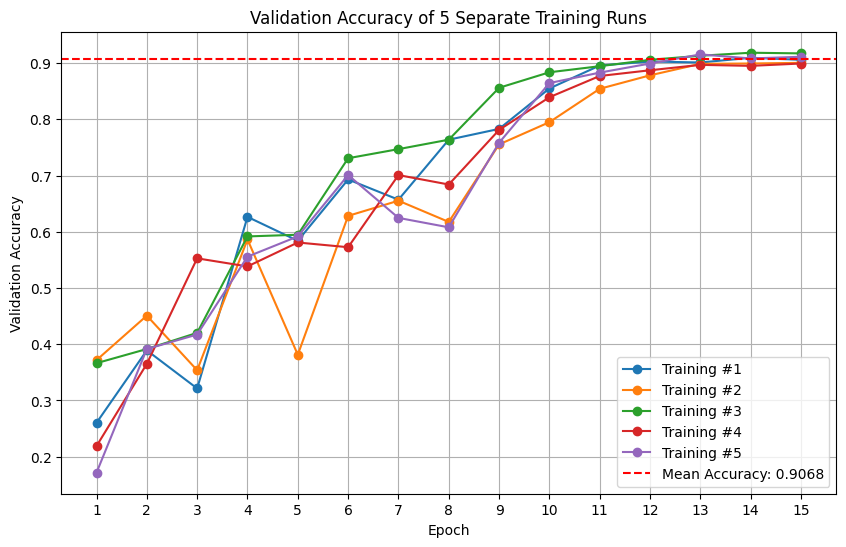

In [18]:
# plot the accuracies of the 5 runs, each one with markers and a legend, and also plot the mean accuracy with a dashed line, the x-axis is strictly the epoch number from 1 to 15.
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), shufflenet_v2_student_history1["val_accuracy"], marker="o", label="Training #1")
plt.plot(range(1, epochs + 1), shufflenet_v2_student_history2["val_accuracy"], marker="o", label="Training #2")
plt.plot(range(1, epochs + 1), shufflenet_v2_student_history3["val_accuracy"], marker="o", label="Training #3")
plt.plot(range(1, epochs + 1), shufflenet_v2_student_history4["val_accuracy"], marker="o", label="Training #4")
plt.plot(range(1, epochs + 1), shufflenet_v2_student_history5["val_accuracy"], marker="o", label="Training #5")
plt.axhline(mean_acc, color="r", linestyle="--", label=f"Mean Accuracy: {mean_acc:.4f}")
plt.title("Validation Accuracy of 5 Separate Training Runs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.xticks(range(1, epochs + 1))
plt.grid()
plt.legend()
plt.show()